# Heart Disease — Intelligent System & Business Analytics
### UCI Cleveland Dataset | Full ML Pipeline
---
**Sections:**
1. Data Preparation (Understanding → Cleaning → EDA → Preprocessing)
2. Clustering (Unsupervised) — K-Means + Silhouette + DBI
3. Classification (Supervised) — Random Forest + Gradient Boosting + Logistic Regression


## 📦 Imports & Theme Setup

In [397]:
import pandas as pd
import numpy as np
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import seaborn as sns
from scipy import stats
from scipy.stats import skew, kurtosis
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.cluster import KMeans
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                              accuracy_score, f1_score, roc_auc_score,
                              classification_report, confusion_matrix, roc_curve)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
from statsmodels.stats.outliers_influence import variance_inflation_factor
import os, json

os.makedirs('/home/claude/figures', exist_ok=True)

# ─── THEME ────────────────────────────────────────────────────────────────────
BG     = '#0d1117'
PANEL  = '#161b22'
PANEL2 = '#1c2230'
GRID   = '#21262d'
TEXT   = '#e6edf3'
MUTED  = '#8b949e'
BLUE   = '#58a6ff'
TEAL   = '#2dd4bf'
AMBER  = '#fbbf24'
ROSE   = '#f87171'
PURPLE = '#a78bfa'
GREEN  = '#4ade80'
PAL    = [BLUE, ROSE, TEAL, AMBER, PURPLE, GREEN]

plt.rcParams.update({
    'figure.facecolor': BG, 'axes.facecolor': PANEL,
    'axes.edgecolor': GRID, 'axes.labelcolor': TEXT,
    'text.color': TEXT, 'xtick.color': MUTED, 'ytick.color': MUTED,
    'grid.color': GRID, 'grid.alpha': 0.8,
    'font.family': 'DejaVu Sans', 'font.size': 10,
    'axes.titlesize': 12, 'axes.titleweight': 'bold',
    'axes.titlepad': 10, 'figure.dpi': 120,
    'savefig.dpi': 150, 'savefig.bbox': 'tight',
    'savefig.facecolor': BG, 'legend.facecolor': PANEL2,
    'legend.edgecolor': GRID,
})

results = {}

# ══════════════════════════════════════════════════════════════════════════════

## 1.1 — Data Understanding

In [398]:


data_path = r"C:\intelligent system mini project\heart+disease\processed.cleveland.data"

# Real column names from UCI documentation
COLS = [
    'age',           # Age in years
    'sex',           # 1 = male, 0 = female
    'cp',            # Chest pain type (1-4)
    'trestbps',      # Resting blood pressure (mmHg)
    'chol',          # Serum cholesterol (mg/dl)
    'fbs',           # Fasting blood sugar > 120 mg/dl (1=true)
    'restecg',       # Resting ECG results (0,1,2)
    'thalach',       # Max heart rate achieved (bpm)
    'exang',         # Exercise induced angina (1=yes)
    'oldpeak',       # ST depression induced by exercise
    'slope',         # Slope of peak exercise ST segment
    'ca',            # Number of major vessels (0-3) colored by fluoroscopy
    'thal',          # Thalassemia (3=normal, 6=fixed defect, 7=reversable)
    'target'         # Diagnosis (0=no disease, 1-4=disease present)
]

df = pd.read_csv(data_path, header=None, names=COLS, na_values='NAN')

In [399]:
# 1.1.1 Read Data
print({df.shape})

{(303, 14)}


In [400]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [401]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,45.0,1.0,1.0,110.0,264.0,0.0,0.0,132.0,0.0,1.2,2.0,0.0,7.0,1
299,68.0,1.0,4.0,144.0,193.0,1.0,0.0,141.0,0.0,3.4,2.0,2.0,7.0,2
300,57.0,1.0,4.0,130.0,131.0,0.0,0.0,115.0,1.0,1.2,2.0,1.0,7.0,3
301,57.0,0.0,2.0,130.0,236.0,0.0,2.0,174.0,0.0,0.0,2.0,1.0,3.0,1
302,38.0,1.0,3.0,138.0,175.0,0.0,0.0,173.0,0.0,0.0,1.0,?,3.0,0


In [402]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    object 
 12  thal      303 non-null    object 
 13  target    303 non-null    int64  
dtypes: float64(11), int64(1), object(2)
memory usage: 33.3+ KB


In [403]:
df.value_counts()

age   sex  cp   trestbps  chol   fbs  restecg  thalach  exang  oldpeak  slope  ca   thal  target
29.0  1.0  2.0  130.0     204.0  0.0  2.0      202.0    0.0    0.0      1.0    0.0  3.0   0         1
34.0  0.0  2.0  118.0     210.0  0.0  0.0      192.0    0.0    0.7      1.0    0.0  3.0   0         1
      1.0  1.0  118.0     182.0  0.0  2.0      174.0    0.0    0.0      1.0    0.0  3.0   0         1
35.0  0.0  4.0  138.0     183.0  0.0  0.0      182.0    0.0    1.4      1.0    0.0  3.0   0         1
      1.0  2.0  122.0     192.0  0.0  0.0      174.0    0.0    0.0      1.0    0.0  3.0   0         1
                                                                                                   ..
71.0  0.0  3.0  110.0     265.0  1.0  2.0      130.0    0.0    0.0      1.0    1.0  3.0   0         1
           4.0  112.0     149.0  0.0  0.0      125.0    0.0    1.6      2.0    0.0  3.0   0         1
74.0  0.0  2.0  120.0     269.0  0.0  2.0      121.0    1.0    0.2      1.0    1.0  3.0

In [404]:

print(df.sample(5, random_state=100).to_string())

      age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  slope   ca thal  target
69   46.0  1.0  3.0     150.0  231.0  0.0      0.0    147.0    0.0      3.6    2.0  0.0  3.0       1
300  57.0  1.0  4.0     130.0  131.0  0.0      0.0    115.0    1.0      1.2    2.0  1.0  7.0       3
220  41.0  0.0  3.0     112.0  268.0  0.0      2.0    172.0    1.0      0.0    1.0  0.0  3.0       0
134  43.0  0.0  3.0     122.0  213.0  0.0      0.0    165.0    0.0      0.2    2.0  0.0  3.0       0
7    57.0  0.0  4.0     120.0  354.0  0.0      0.0    163.0    1.0      0.6    1.0  0.0  3.0       0


In [405]:

print(list(df.columns))

['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


In [406]:

print(df.describe().round(2).to_string())

          age     sex      cp  trestbps    chol     fbs  restecg  thalach   exang  oldpeak   slope  target
count  303.00  303.00  303.00    303.00  303.00  303.00   303.00   303.00  303.00   303.00  303.00  303.00
mean    54.44    0.68    3.16    131.69  246.69    0.15     0.99   149.61    0.33     1.04    1.60    0.94
std      9.04    0.47    0.96     17.60   51.78    0.36     0.99    22.88    0.47     1.16    0.62    1.23
min     29.00    0.00    1.00     94.00  126.00    0.00     0.00    71.00    0.00     0.00    1.00    0.00
25%     48.00    0.00    3.00    120.00  211.00    0.00     0.00   133.50    0.00     0.00    1.00    0.00
50%     56.00    1.00    3.00    130.00  241.00    0.00     1.00   153.00    0.00     0.80    2.00    0.00
75%     61.00    1.00    4.00    140.00  275.00    0.00     2.00   166.00    1.00     1.60    2.00    2.00
max     77.00    1.00    4.00    200.00  564.00    1.00     2.00   202.00    1.00     6.20    3.00    4.00


In [407]:
for c in df.columns:
    print(f"  {c:12s}: {df[c].nunique()} unique  | sample: {sorted(df[c].dropna().unique())[:6]}")

  age         : 41 unique  | sample: [np.float64(29.0), np.float64(34.0), np.float64(35.0), np.float64(37.0), np.float64(38.0), np.float64(39.0)]
  sex         : 2 unique  | sample: [np.float64(0.0), np.float64(1.0)]
  cp          : 4 unique  | sample: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]
  trestbps    : 50 unique  | sample: [np.float64(94.0), np.float64(100.0), np.float64(101.0), np.float64(102.0), np.float64(104.0), np.float64(105.0)]
  chol        : 152 unique  | sample: [np.float64(126.0), np.float64(131.0), np.float64(141.0), np.float64(149.0), np.float64(157.0), np.float64(160.0)]
  fbs         : 2 unique  | sample: [np.float64(0.0), np.float64(1.0)]
  restecg     : 3 unique  | sample: [np.float64(0.0), np.float64(1.0), np.float64(2.0)]
  thalach     : 91 unique  | sample: [np.float64(71.0), np.float64(88.0), np.float64(90.0), np.float64(95.0), np.float64(96.0), np.float64(97.0)]
  exang       : 2 unique  | sample: [np.float64(0.0), np.float64(1.0)

## 1.2 — Data Cleaning

In [408]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [409]:
df.duplicated().sum()

np.int64(0)

In [410]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    object 
 12  thal      303 non-null    object 
 13  target    303 non-null    int64  
dtypes: float64(11), int64(1), object(2)
memory usage: 33.3+ KB


In [411]:
# Binary/categorical columns
cat_cols = ['sex','cp','fbs','restecg','exang','slope','ca','thal']
num_cols = ['age','trestbps','chol','thalach','oldpeak']
df['ca']   = pd.to_numeric(df['ca'],   errors='coerce')
df['thal'] = pd.to_numeric(df['thal'],  errors='coerce')
print(f"[1.2.3] Corrected ca & thal to numeric")

[1.2.3] Corrected ca & thal to numeric


In [412]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [413]:
inv_bp = (df['trestbps'] == 0).sum()
inv_bp

np.int64(0)

In [414]:
df = df[df['trestbps'] > 0]
print(f"\n[1.2.5] Invalid trestbps=0 rows removed: {inv_bp}")


[1.2.5] Invalid trestbps=0 rows removed: 0


In [415]:
# thal: 3=normal, 6=fixed defect, 7=reversable defect → map to 0,1,2
df['thal'] = df['thal'].replace({3.0: 0, 6.0: 1, 7.0: 2})
df["thal"].fillna(0, inplace=True)
df["ca"].fillna(0, inplace=True)
# cp: already 1-4, rename to 0-3 for clarity
df['cp'] = df['cp'] - 1
print(f"[1.2.6] Standardized thal (3→0, 6→1, 7→2) and cp (1-4 → 0-3)")

[1.2.6] Standardized thal (3→0, 6→1, 7→2) and cp (1-4 → 0-3)


C:\Users\moham\AppData\Local\Temp\ipykernel_228\3062727647.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["thal"].fillna(0, inplace=True)
C:\Users\moham\AppData\Local\Temp\ipykernel_228\3062727647.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing '

In [416]:
# 1.2.8 Outlier Flagging (IQR method)
print(f"\n[1.2.8] Outlier Flagging (IQR):")
outlier_flags = pd.DataFrame(index=df.index)
for col in num_cols:
    Q1,Q3=df[col].quantile(0.25),df[col].quantile(0.75)
    IQR=Q3-Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outlier = (df[col] < lo) | (df[col] > hi)
    outlier_flags[col] = outlier
    print(f"  {col:10s}: {outlier.sum():3d} outliers  [{lo:.1f}, {hi:.1f}]")

df['outlier_flag'] = outlier_flags.any(axis=1).astype(int)
print(f"\n  Total rows with ≥1 outlier: {df['outlier_flag'].sum()}")

# Binarize target: 0 = no disease, 1 = disease present
df['target_binary'] = (df['target'] > 0).astype(int)

print(f"\nClean dataset shape: {df.shape}")
results['clean_shape'] = df.shape


[1.2.8] Outlier Flagging (IQR):
  age       :   0 outliers  [28.5, 80.5]
  trestbps  :   9 outliers  [90.0, 170.0]
  chol      :   5 outliers  [115.0, 371.0]
  thalach   :   1 outliers  [84.8, 214.8]
  oldpeak   :   5 outliers  [-2.4, 4.0]

  Total rows with ≥1 outlier: 19

Clean dataset shape: (303, 16)


## 1.3 — Exploratory Data Analysis (EDA)

In [417]:

cat_plot_cols = ['sex','cp','fbs','restecg','exang','slope','ca','thal']

In [418]:
print("\n  Skewness & Kurtosis:")
sk_table = []
for col in num_cols:
    s = skew(df[col].dropna())
    k = kurtosis(df[col].dropna())
    sk_table.append({'Feature': col, 'Skewness': round(s,3), 'Kurtosis': round(k,3),
                     'Skew Level': 'High' if abs(s)>1 else 'Moderate' if abs(s)>0.5 else 'Low'})
    print(f"  {col:12s}: skewness={s:+.3f}  kurtosis={k:+.3f}")
sk_df = pd.DataFrame(sk_table)

# 1.3.1.4 Log transform for skewed features
skewed_feats = [r['Feature'] for r in sk_table if abs(r['Skewness']) > 0.75]
print(f"\n  Applying log1p to skewed features: {skewed_feats}")
for col in skewed_feats:
    df[f'{col}_log'] = np.log1p(df[col])


  Skewness & Kurtosis:
  age         : skewness=-0.208  kurtosis=-0.535
  trestbps    : skewness=+0.703  kurtosis=+0.846
  chol        : skewness=+1.130  kurtosis=+4.398
  thalach     : skewness=-0.535  kurtosis=-0.072
  oldpeak     : skewness=+1.263  kurtosis=+1.530

  Applying log1p to skewed features: ['chol', 'oldpeak']


In [419]:
# 1.3.2 Bivariate Analysis
print("\n[1.3.2] Bivariate Analysis")

# Correlation matrix for later plots
corr = df[num_cols + cat_plot_cols + ['target_binary']].corr()


[1.3.2] Bivariate Analysis


In [420]:
# 1.3.2.2 Scatter Plots (top correlated pairs with target)
target_corr = corr['target_binary'].drop('target_binary').abs().sort_values(ascending=False)
top4 = target_corr.head(4).index.tolist()
print(f"  Top 4 features correlated with target: {top4}")

  Top 4 features correlated with target: ['thal', 'ca', 'exang', 'oldpeak']


In [421]:
# 1.3.3 Multivariate Analysis
print("\n[1.3.3] Multivariate Analysis")

# 1.3.3.2 VIF — Multicollinearity
print("\n  [1.3.3.2] VIF — Multicollinearity Check:")
vif_data = df[num_cols].dropna()
vif_df = pd.DataFrame()
vif_df['Feature'] = num_cols
vif_df['VIF'] = [variance_inflation_factor(vif_data.values, i) for i in range(len(num_cols))]
print(vif_df.to_string(index=False))
results['vif'] = vif_df.to_dict('records')

# 1.3.3.3 PCA
print("\n  [1.3.3.3] PCA:")
scaler_pca = StandardScaler()
X_pca_in = df[num_cols + cat_plot_cols].copy().fillna(df.median())
X_pca_scaled = scaler_pca.fit_transform(X_pca_in)
pca = PCA()
pca.fit(X_pca_scaled)
var_ratio = pca.explained_variance_ratio_
cum_var = np.cumsum(var_ratio)
n_comp_90 = np.argmax(cum_var >= 0.90) + 1
print(f"  Components to explain 90% variance: {n_comp_90}")


[1.3.3] Multivariate Analysis

  [1.3.3.2] VIF — Multicollinearity Check:
 Feature       VIF
     age 36.685632
trestbps 55.971579
    chol 24.354973
 thalach 29.326738
 oldpeak  2.084119

  [1.3.3.3] PCA:
  Components to explain 90% variance: 10


## 1.4 — Data Preprocessing

In [422]:
cat_plot_cols = ['sex','cp','fbs','restecg','exang','slope','ca','thal']
df_proc = df[num_cols + cat_plot_cols + ['target_binary']].copy()
X_raw = df_proc.drop('target_binary', axis=1)
y     = df_proc['target_binary']

In [423]:
scaler = RobustScaler() 
X_scaled = pd.DataFrame(scaler.fit_transform(X_raw), columns=X_raw.columns)
X_scaled.shape

(303, 13)

In [424]:

X_treated = X_raw.copy()

for col in X_treated.columns:
    if X_treated[col].isnull().sum() > 0:
        X_treated[col].fillna(X_treated[col].median(), inplace=True)
for col in num_cols:
    Q1, Q3 = X_treated[col].quantile(0.25), X_treated[col].quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    X_treated[col] = X_treated[col].clip(lo, hi)
X_treated_scaled = pd.DataFrame(scaler.fit_transform(X_treated), columns=X_treated.columns)

In [425]:
X_treated_scaled = X_treated_scaled.fillna(X_treated_scaled.median())
print(f"\n[1.4.4] Class distribution before SMOTE:\n{y.value_counts().to_string()}")
smote = SMOTE(random_state=42)
X_sm, y_sm = smote.fit_resample(X_treated_scaled, y)
print(f"Class distribution after SMOTE:\n{pd.Series(y_sm).value_counts().to_string()}")
results['smote_shape'] = X_sm.shape


[1.4.4] Class distribution before SMOTE:
target_binary
0    164
1    139
Class distribution after SMOTE:
target_binary
0    164
1    164


In [426]:
# 1.4.5 Train & Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_sm, y_sm, test_size=0.2, random_state=42, stratify=y_sm)
print(f"\n[1.4.5] Train: {X_train.shape} | Test: {X_test.shape}")
results['train_size'] = X_train.shape[0]
results['test_size']  = X_test.shape[0]


[1.4.5] Train: (262, 13) | Test: (66, 13)


## 2.1–2.2 — K-Means Clustering

In [427]:

k_range = range(2, 9)
inertias, sil_scores, dbi_scores = [], [], []
for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=20, random_state=42)
    labels = km.fit_predict(X_cluster)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_cluster, labels))
    dbi_scores.append(davies_bouldin_score(X_cluster, labels))
    print(f"  K={k}  Inertia={km.inertia_:.1f}  Silhouette={sil_scores[-1]:.4f}  DBI={dbi_scores[-1]:.4f}")

best_k = k_range[np.argmax(sil_scores)]
print(f"\nOptimal K = {best_k} (highest Silhouette)")

c:\Users\moham\anaconda3\envs\HESHOO\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


  K=2  Inertia=1446.8  Silhouette=0.1864  DBI=1.9458
  K=3  Inertia=1298.0  Silhouette=0.1392  DBI=2.0725


c:\Users\moham\anaconda3\envs\HESHOO\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\moham\anaconda3\envs\HESHOO\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


  K=4  Inertia=1192.7  Silhouette=0.1384  DBI=1.9904
  K=5  Inertia=1117.5  Silhouette=0.1258  DBI=1.9855


c:\Users\moham\anaconda3\envs\HESHOO\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\moham\anaconda3\envs\HESHOO\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


  K=6  Inertia=1068.7  Silhouette=0.1262  DBI=1.8874
  K=7  Inertia=1018.5  Silhouette=0.1169  DBI=2.0020


c:\Users\moham\anaconda3\envs\HESHOO\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\moham\anaconda3\envs\HESHOO\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


  K=8  Inertia=981.1  Silhouette=0.1156  DBI=1.9487

Optimal K = 2 (highest Silhouette)


In [428]:

km_final = KMeans(n_clusters=best_k, init='k-means++', n_init=30, random_state=42)
cluster_labels = km_final.fit_predict(X_cluster)

# 2.2 Evaluation Metrics
sil_final = silhouette_score(X_cluster, cluster_labels)
dbi_final = davies_bouldin_score(X_cluster, cluster_labels)
print(f"\n[2.2] Final Clustering Metrics (K={best_k}):")
print(f"  Silhouette Score : {sil_final:.4f}  (higher is better, max=1)")
print(f"  Davies-Bouldin   : {dbi_final:.4f}  (lower is better, min=0)")
results['clustering'] = {'best_k': best_k, 'silhouette': round(sil_final,4), 'dbi': round(dbi_final,4)}


[2.2] Final Clustering Metrics (K=2):
  Silhouette Score : 0.1864  (higher is better, max=1)
  Davies-Bouldin   : 1.9458  (lower is better, min=0)


c:\Users\moham\anaconda3\envs\HESHOO\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


## 2.3–2.4 — Classification

In [429]:
print("\n" + "═"*60)
print("  2.3  CLASSIFICATION")
print("═"*60)

# ── Primary Model: Random Forest ──────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=4,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf    = rf.predict(X_test)
y_proba_rf   = rf.predict_proba(X_test)[:, 1]

acc_rf   = accuracy_score(y_test, y_pred_rf)
f1_rf    = f1_score(y_test, y_pred_rf)
auc_rf   = roc_auc_score(y_test, y_proba_rf)

print(f"\n[Random Forest]")
print(f"  Accuracy : {acc_rf:.4f}")
print(f"  F1-Score : {f1_rf:.4f}")
print(f"  ROC-AUC  : {auc_rf:.4f}")
print(f"\n  Classification Report:\n{classification_report(y_test, y_pred_rf)}")

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_acc = cross_val_score(rf, X_sm, y_sm, cv=cv, scoring='accuracy')
cv_auc = cross_val_score(rf, X_sm, y_sm, cv=cv, scoring='roc_auc')
print(f"  5-Fold CV Accuracy : {cv_acc.mean():.4f} ± {cv_acc.std():.4f}")
print(f"  5-Fold CV AUC      : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")

results['rf'] = {
    'accuracy': round(acc_rf, 4), 'f1': round(f1_rf, 4), 'auc': round(auc_rf, 4),
    'cv_acc': round(cv_acc.mean(), 4), 'cv_auc': round(cv_auc.mean(), 4)
}


════════════════════════════════════════════════════════════
  2.3  CLASSIFICATION
════════════════════════════════════════════════════════════

[Random Forest]
  Accuracy : 0.8788
  F1-Score : 0.8788
  ROC-AUC  : 0.9458

  Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.88      0.88        33
           1       0.88      0.88      0.88        33

    accuracy                           0.88        66
   macro avg       0.88      0.88      0.88        66
weighted avg       0.88      0.88      0.88        66

  5-Fold CV Accuracy : 0.8508 ± 0.0253
  5-Fold CV AUC      : 0.9231 ± 0.0191


In [430]:

gb = GradientBoostingClassifier(
    n_estimators=200, learning_rate=0.08,
    max_depth=4, subsample=0.85, random_state=42
)
gb.fit(X_train, y_train)
y_pred_gb    = gb.predict(X_test)
y_proba_gb   = gb.predict_proba(X_test)[:, 1]

acc_gb  = accuracy_score(y_test, y_pred_gb)
f1_gb   = f1_score(y_test, y_pred_gb)
auc_gb  = roc_auc_score(y_test, y_proba_gb)

print(f"\n[Gradient Boosting]")
print(f"  Accuracy : {acc_gb:.4f}")
print(f"  F1-Score : {f1_gb:.4f}")
print(f"  ROC-AUC  : {auc_gb:.4f}")

results['gb'] = {'accuracy': round(acc_gb,4), 'f1': round(f1_gb,4), 'auc': round(auc_gb,4)}


[Gradient Boosting]
  Accuracy : 0.8333
  F1-Score : 0.8358
  ROC-AUC  : 0.9137


In [431]:
lr = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr   = lr.predict(X_test)
y_proba_lr  = lr.predict_proba(X_test)[:, 1]

acc_lr  = accuracy_score(y_test, y_pred_lr)
f1_lr   = f1_score(y_test, y_pred_lr)
auc_lr  = roc_auc_score(y_test, y_proba_lr)

print(f"\n[Logistic Regression — comparison]")
print(f"  Accuracy : {acc_lr:.4f}")
print(f"  F1-Score : {f1_lr:.4f}")
print(f"  ROC-AUC  : {auc_lr:.4f}")

results['lr'] = {'accuracy': round(acc_lr,4), 'f1': round(f1_lr,4), 'auc': round(auc_lr,4)}


[Logistic Regression — comparison]
  Accuracy : 0.8333
  F1-Score : 0.8358
  ROC-AUC  : 0.9256


## Visualizations

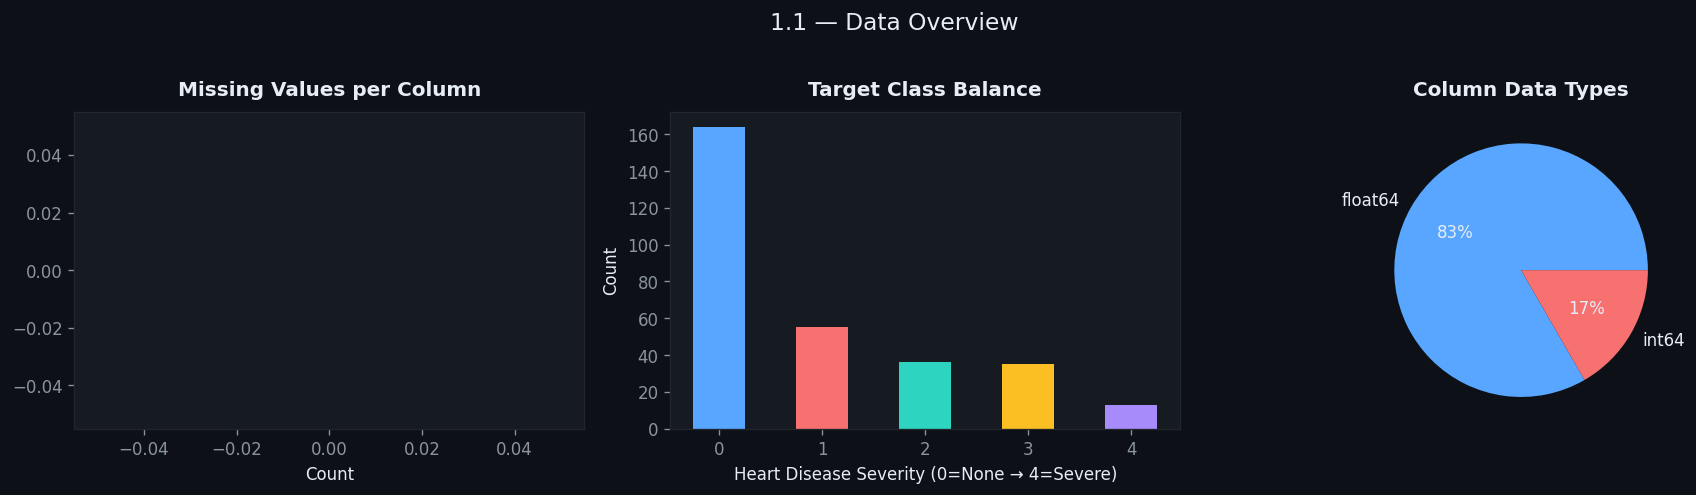

In [432]:
# 1.1.9 Figure 1: Data Overview
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('1.1 — Data Overview', fontsize=14, color=TEXT, y=1.02)

# Missing values
miss = df.isnull().sum()
miss = miss[miss > 0]
axes[0].barh(miss.index, miss.values, color=AMBER)
axes[0].set_title('Missing Values per Column')
axes[0].set_xlabel('Count')

# Class balance
vc = df['target'].value_counts().sort_index()
colors_bal = [BLUE, ROSE, TEAL, AMBER, PURPLE]
axes[1].bar(vc.index, vc.values, color=colors_bal[:len(vc)], width=0.5)
axes[1].set_title('Target Class Balance')
axes[1].set_xlabel('Heart Disease Severity (0=None → 4=Severe)')
axes[1].set_ylabel('Count')

# Data types
dtype_counts = df.dtypes.value_counts()
axes[2].pie(dtype_counts.values, labels=[str(d) for d in dtype_counts.index],
            colors=PAL[:len(dtype_counts)], autopct='%1.0f%%',
            textprops={'color': TEXT})
axes[2].set_title('Column Data Types')

plt.tight_layout()
plt.show()

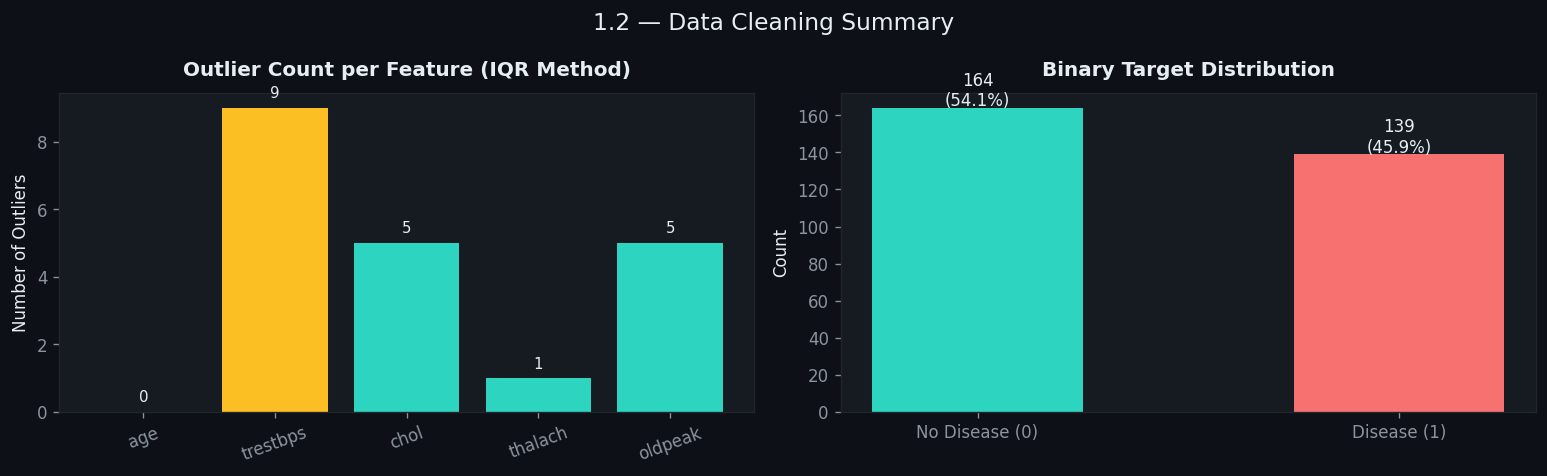

In [433]:
# 1.2.9 Figure 2: Cleaning Summary
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('1.2 — Data Cleaning Summary', fontsize=14, color=TEXT)

# Outlier counts per feature
out_counts = outlier_flags.sum()
bars = axes[0].bar(out_counts.index, out_counts.values,
                   color=[ROSE if v > 10 else AMBER if v > 5 else TEAL for v in out_counts.values])
axes[0].set_title('Outlier Count per Feature (IQR Method)')
axes[0].set_ylabel('Number of Outliers')
axes[0].tick_params(axis='x', rotation=20)
for bar, val in zip(bars, out_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                str(val), ha='center', color=TEXT, fontsize=9)

# Binary target distribution
tbin = df['target_binary'].value_counts()
axes[1].bar(['No Disease (0)', 'Disease (1)'], tbin.values, color=[TEAL, ROSE], width=0.5)
axes[1].set_title('Binary Target Distribution')
axes[1].set_ylabel('Count')
for i, v in enumerate(tbin.values):
    axes[1].text(i, v + 1, f'{v}\n({v/len(df)*100:.1f}%)',
                ha='center', color=TEXT, fontsize=10)

plt.tight_layout()
plt.show()


[1.3.1] Univariate Analysis


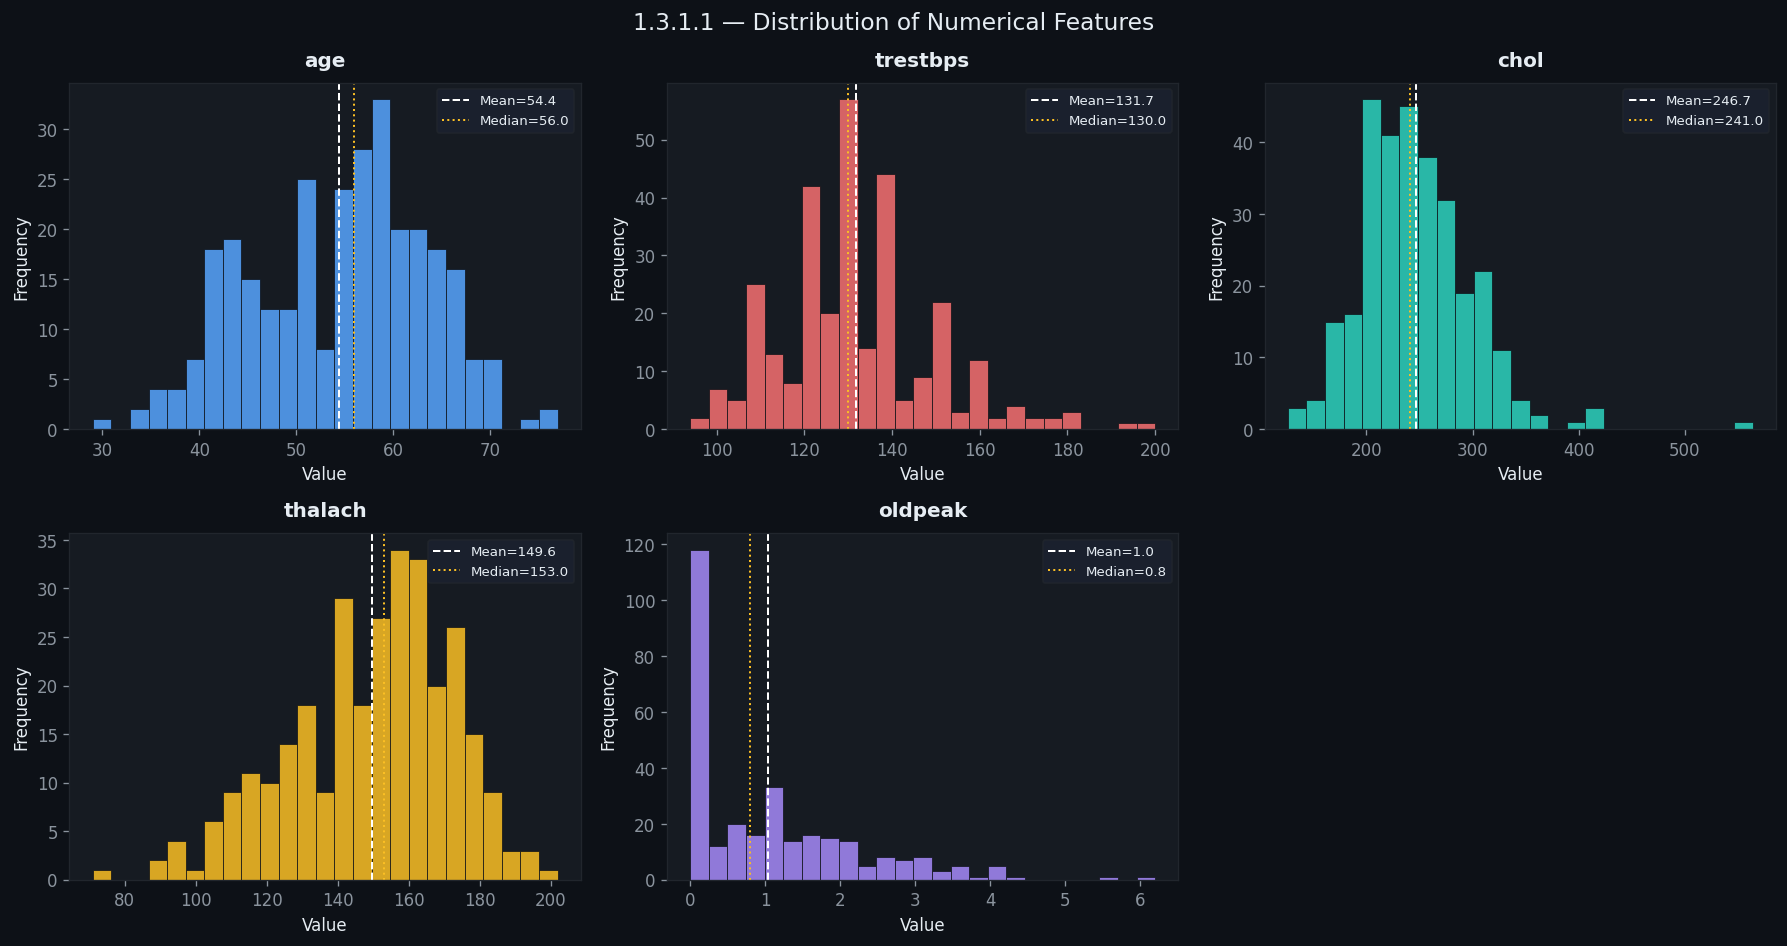

In [434]:
# 1.3.1 Univariate Analysis
print("\n[1.3.1] Univariate Analysis")

# 1.3.1.1 Distribution of numerical features
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('1.3.1.1 — Distribution of Numerical Features', fontsize=14, color=TEXT)
axes = axes.flatten()
for i, col in enumerate(num_cols):
    ax = axes[i]
    data = df[col].dropna()
    ax.hist(data, bins=25, color=PAL[i], alpha=0.85, edgecolor=BG, linewidth=0.5)
    ax.axvline(data.mean(),   color='white', linestyle='--', linewidth=1.2, label=f'Mean={data.mean():.1f}')
    ax.axvline(data.median(), color=AMBER,   linestyle=':',  linewidth=1.2, label=f'Median={data.median():.1f}')
    ax.set_title(col)
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)
axes[5].set_visible(False)
plt.tight_layout()
plt.show()

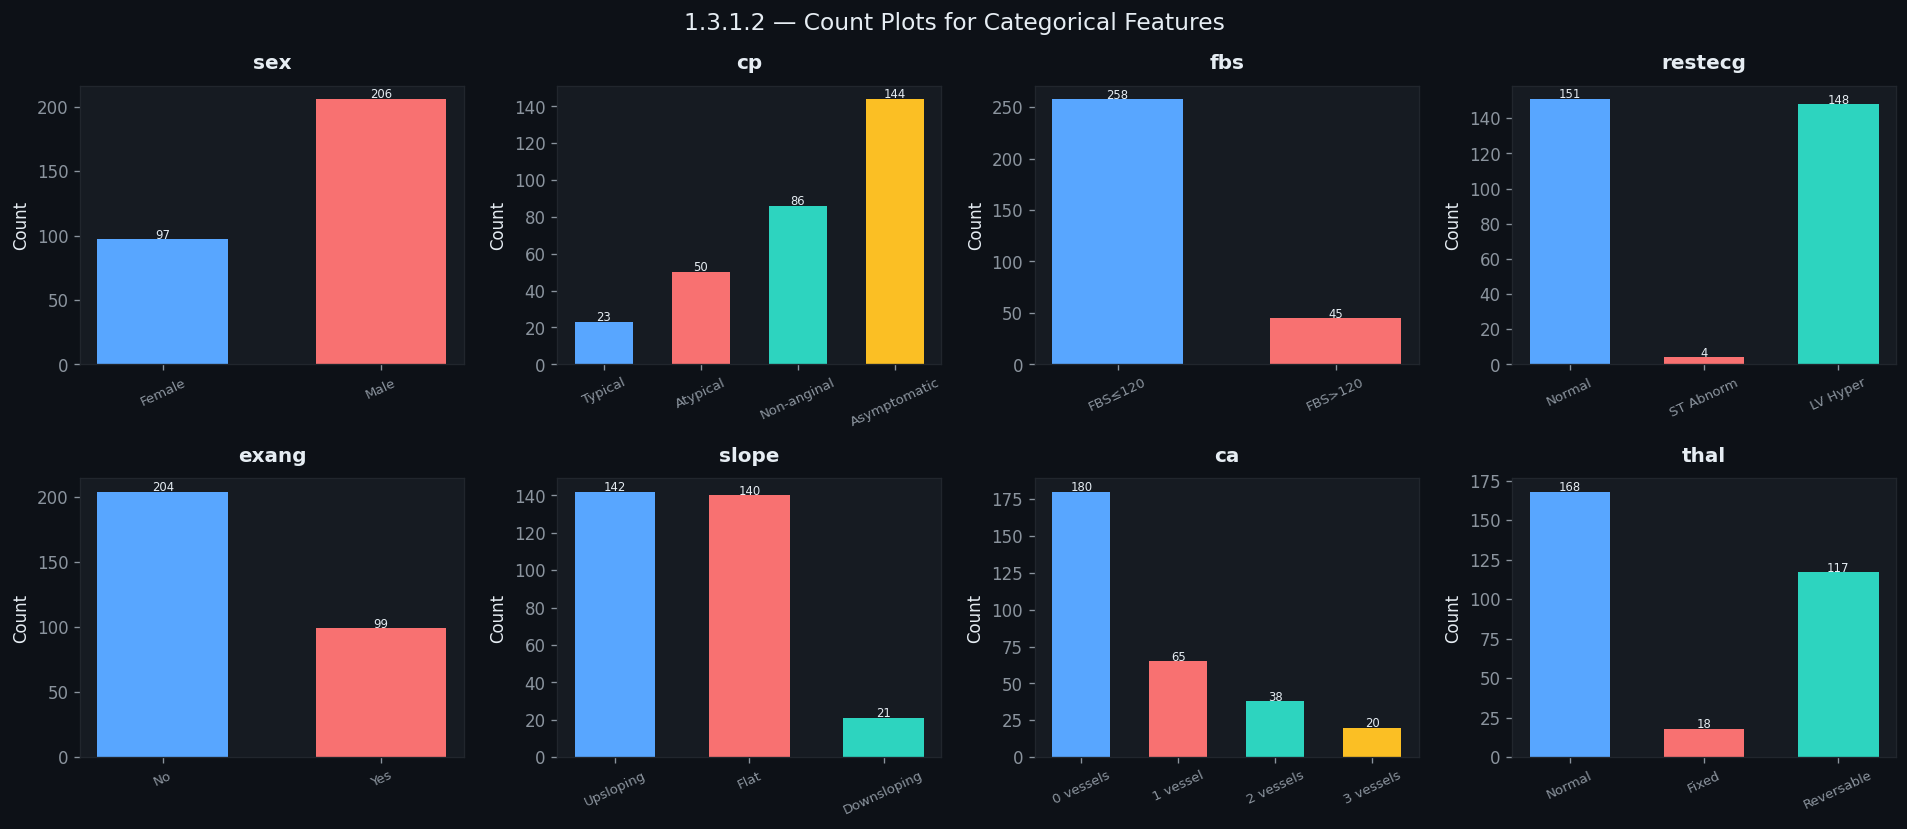

In [435]:
# 1.3.1.2 Count plots for categorical features
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle('1.3.1.2 — Count Plots for Categorical Features', fontsize=14, color=TEXT)
axes = axes.flatten()
labels_map = {
    'sex':     {0:'Female', 1:'Male'},
    'fbs':     {0:'FBS≤120', 1:'FBS>120'},
    'exang':   {0:'No', 1:'Yes'},
    'restecg': {0:'Normal', 1:'ST Abnorm', 2:'LV Hyper'},
    'slope':   {1:'Upsloping', 2:'Flat', 3:'Downsloping'},
    'cp':      {0:'Typical', 1:'Atypical', 2:'Non-anginal', 3:'Asymptomatic'},
    'ca':      {0:'0 vessels', 1:'1 vessel', 2:'2 vessels', 3:'3 vessels'},
    'thal':    {0:'Normal', 1:'Fixed', 2:'Reversable'},
}
for i, col in enumerate(cat_plot_cols):
    ax = axes[i]
    vc = df[col].value_counts().sort_index()
    lmap = labels_map.get(col, {})
    xlabels = [lmap.get(k, str(k)) for k in vc.index]
    bars = ax.bar(range(len(vc)), vc.values, color=PAL[:len(vc)], width=0.6)
    ax.set_xticks(range(len(vc)))
    ax.set_xticklabels(xlabels, rotation=25, fontsize=8)
    ax.set_title(col)
    ax.set_ylabel('Count')
    for bar, val in zip(bars, vc.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                str(val), ha='center', fontsize=7, color=TEXT)
plt.tight_layout()
plt.show()

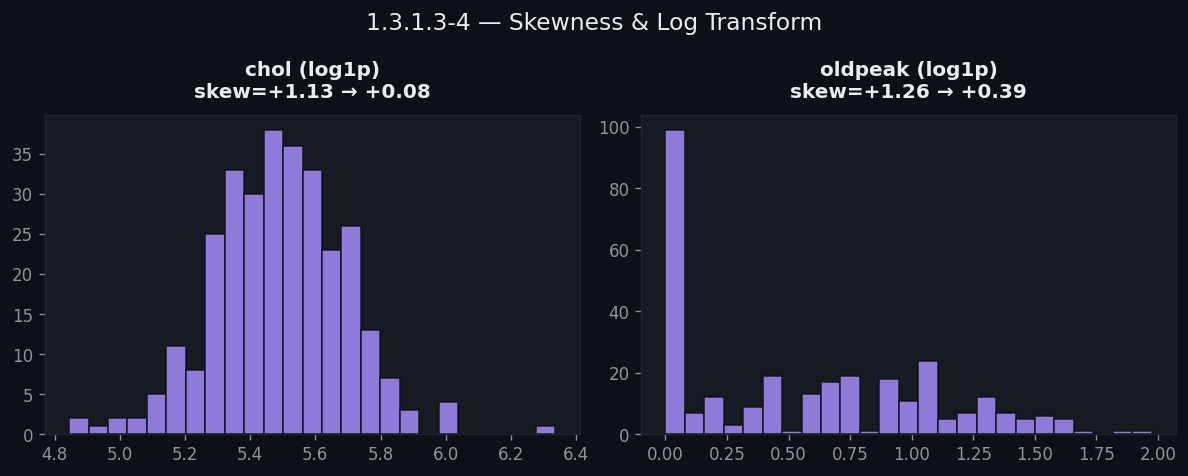

In [436]:
# 1.3.1.3-4 Figure 5: Skewness & Log Transform
fig, axes = plt.subplots(1, len(skewed_feats), figsize=(5*len(skewed_feats), 4))
if len(skewed_feats) == 1:
    axes = [axes]
fig.suptitle('1.3.1.3-4 — Skewness & Log Transform', fontsize=14, color=TEXT)
for i, col in enumerate(skewed_feats):
    axes[i].hist(df[f'{col}_log'], bins=25, color=PURPLE, alpha=0.85, edgecolor=BG)
    axes[i].set_title(f'{col} (log1p)\nskew={skew(df[col].dropna()):+.2f} → {skew(df[f"{col}_log"]):+.2f}')
plt.tight_layout()
plt.show()

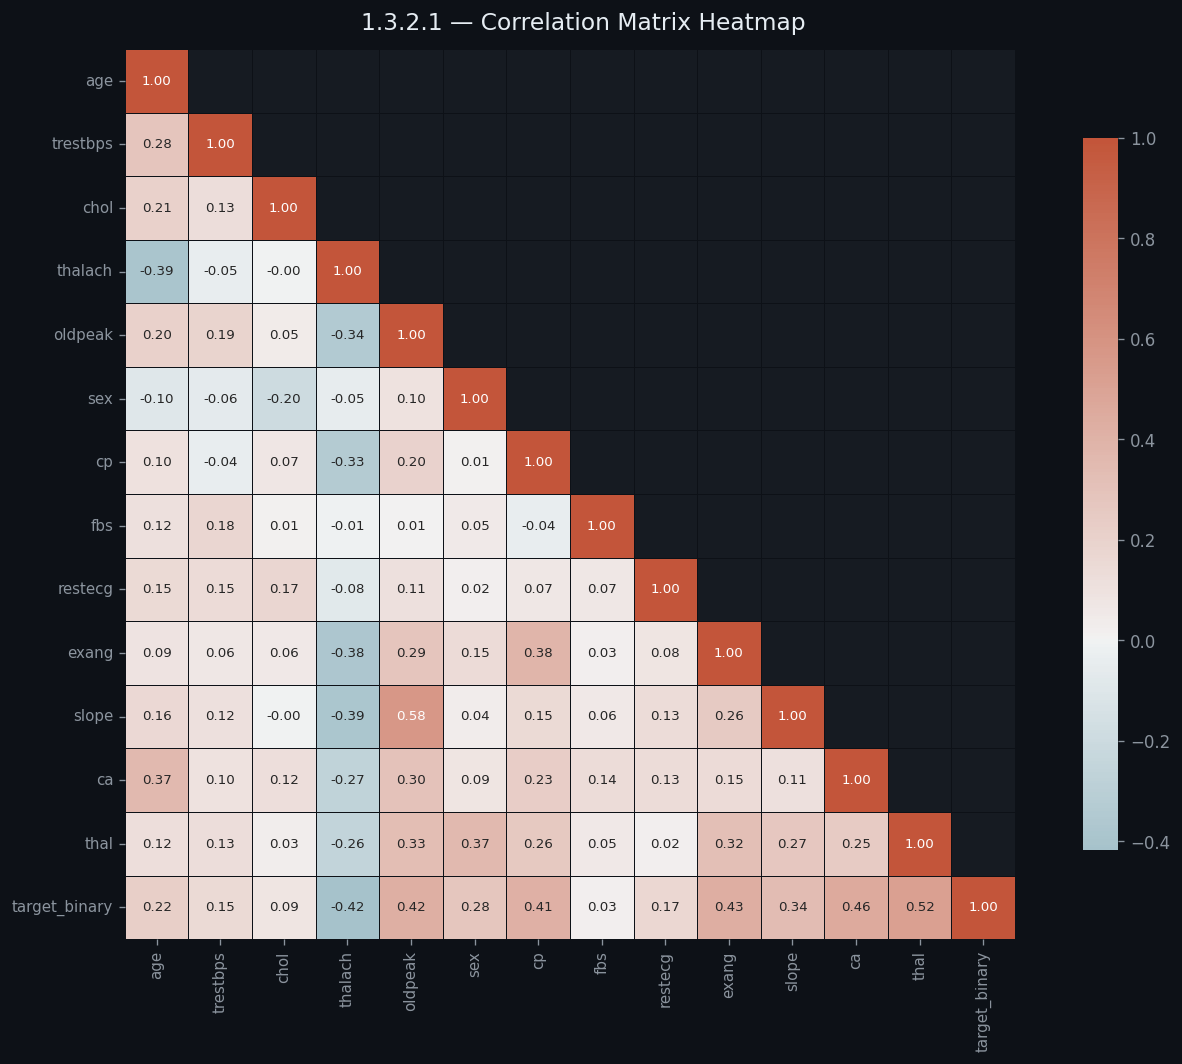

In [437]:
# 1.3.2.1 Figure 6: Correlation Matrix Heatmap
fig, ax = plt.subplots(figsize=(12, 9))
fig.suptitle('1.3.2.1 — Correlation Matrix Heatmap', fontsize=14, color=TEXT)
corr = df[num_cols + cat_plot_cols + ['target_binary']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
cmap = sns.diverging_palette(220, 20, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, center=0, annot=True, fmt='.2f',
            linewidths=0.5, linecolor=BG, ax=ax,
            annot_kws={'size': 8}, square=True,
            cbar_kws={'shrink': 0.8})
ax.tick_params(labelsize=9)
plt.tight_layout()
plt.show()

  Top 4 features correlated with target: ['thal', 'ca', 'exang', 'oldpeak']


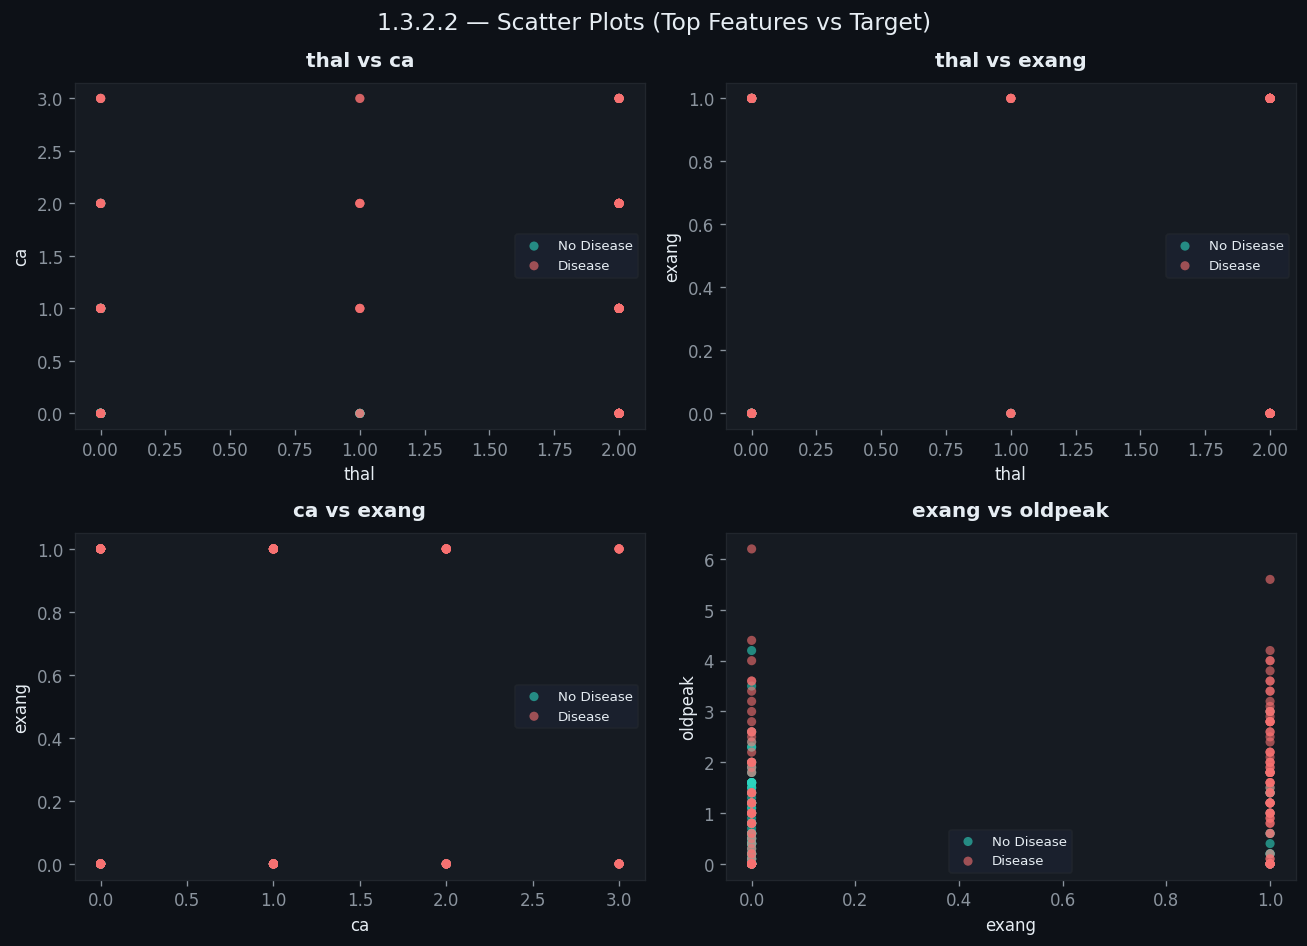

In [438]:
# 1.3.2.2 Figure 7: Scatter Plots (Top Features vs Target)
target_corr = corr['target_binary'].drop('target_binary').abs().sort_values(ascending=False)
top4 = target_corr.head(4).index.tolist()
print(f"  Top 4 features correlated with target: {top4}")

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
fig.suptitle('1.3.2.2 — Scatter Plots (Top Features vs Target)', fontsize=14, color=TEXT)
axes = axes.flatten()
for i, (f1, f2) in enumerate([(top4[0], top4[1]), (top4[0], top4[2]),
                                (top4[1], top4[2]), (top4[2], top4[3])]):
    ax = axes[i]
    for cls, col, lbl in [(0, TEAL, 'No Disease'), (1, ROSE, 'Disease')]:
        mask = df['target_binary'] == cls
        ax.scatter(df.loc[mask, f1], df.loc[mask, f2],
                   c=col, alpha=0.6, s=30, label=lbl, edgecolors='none')
    ax.set_xlabel(f1); ax.set_ylabel(f2)
    ax.set_title(f'{f1} vs {f2}')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

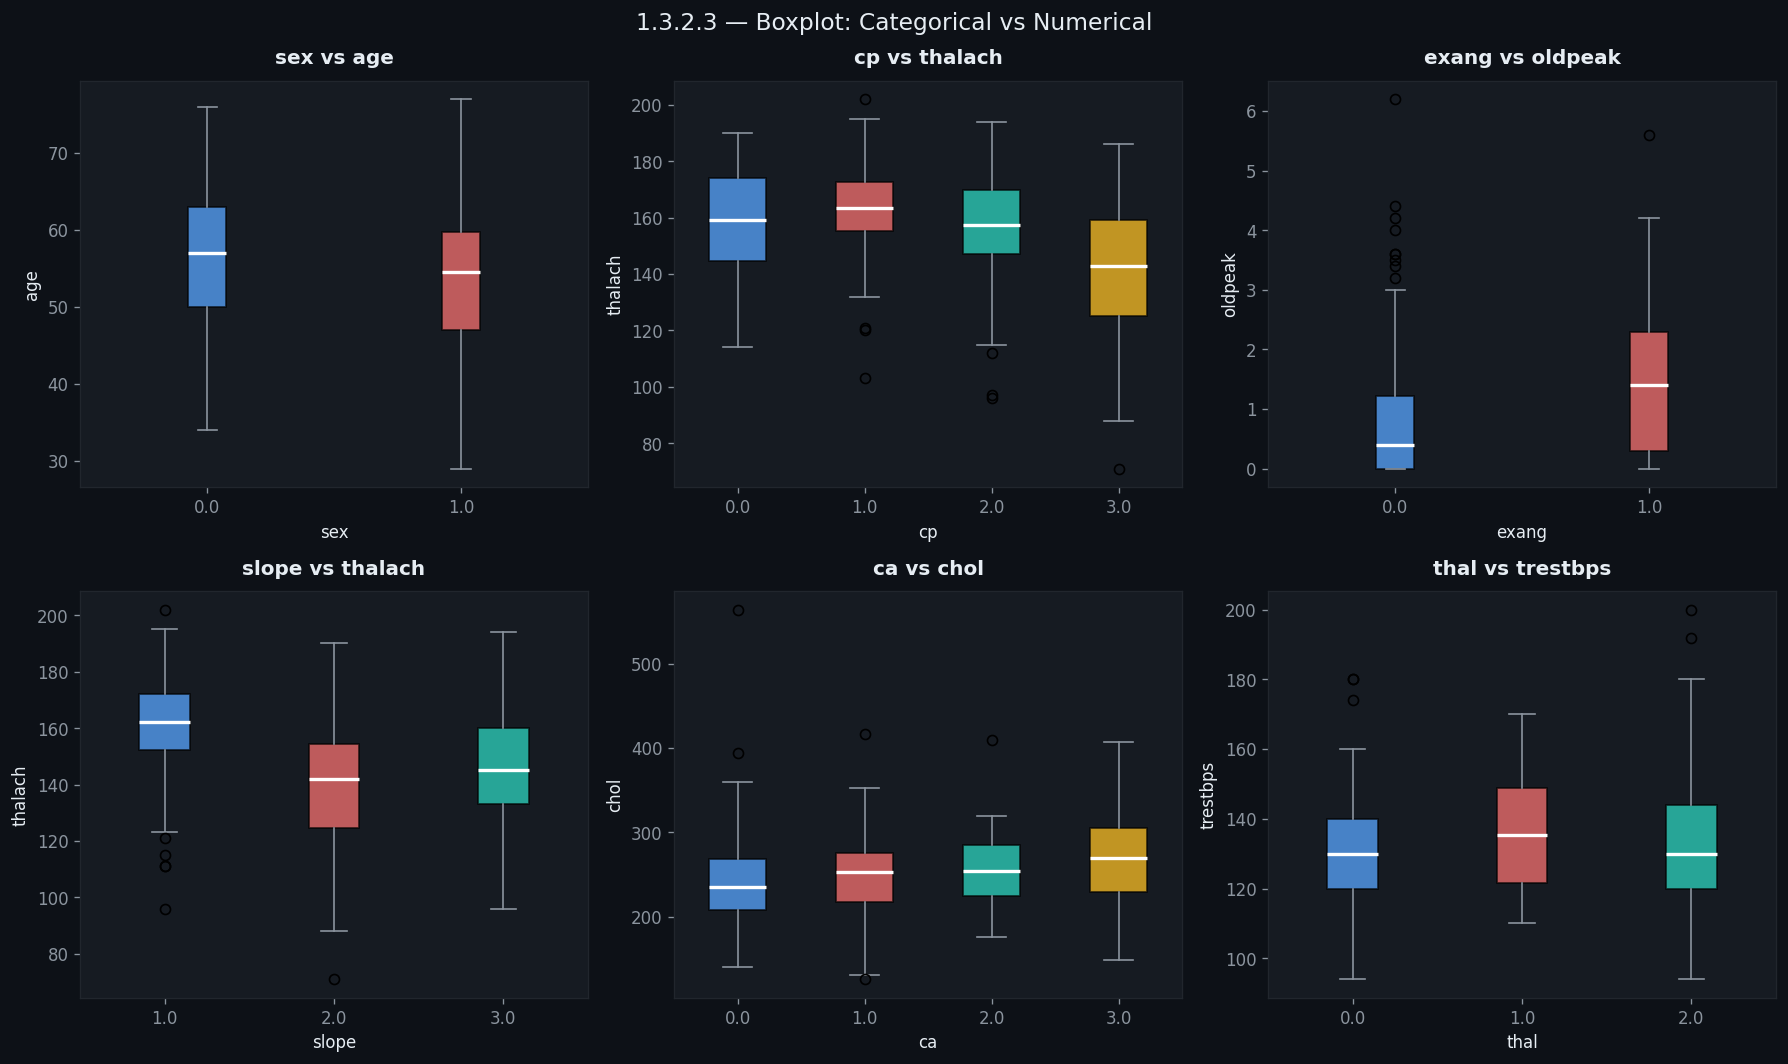

In [439]:
# 1.3.2.3 Figure 8: Boxplot (categorical vs numerical)
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('1.3.2.3 — Boxplot: Categorical vs Numerical', fontsize=14, color=TEXT)
axes = axes.flatten()
pairs = [('sex','age'), ('cp','thalach'), ('exang','oldpeak'),
         ('slope','thalach'), ('ca','chol'), ('thal','trestbps')]
for i, (cat, num) in enumerate(pairs):
    ax = axes[i]
    groups = df.groupby(cat)[num].apply(list)
    bp = ax.boxplot(groups.values, patch_artist=True,
                    medianprops={'color': 'white', 'linewidth': 2})
    for j, patch in enumerate(bp['boxes']):
        patch.set_facecolor(PAL[j % len(PAL)])
        patch.set_alpha(0.75)
    for element in ['whiskers','caps','fliers']:
        for item in bp[element]:
            item.set_color(MUTED)
    ax.set_xticklabels([str(k) for k in groups.index], rotation=0)
    ax.set_title(f'{cat} vs {num}')
    ax.set_xlabel(cat); ax.set_ylabel(num)
plt.tight_layout()
plt.show()

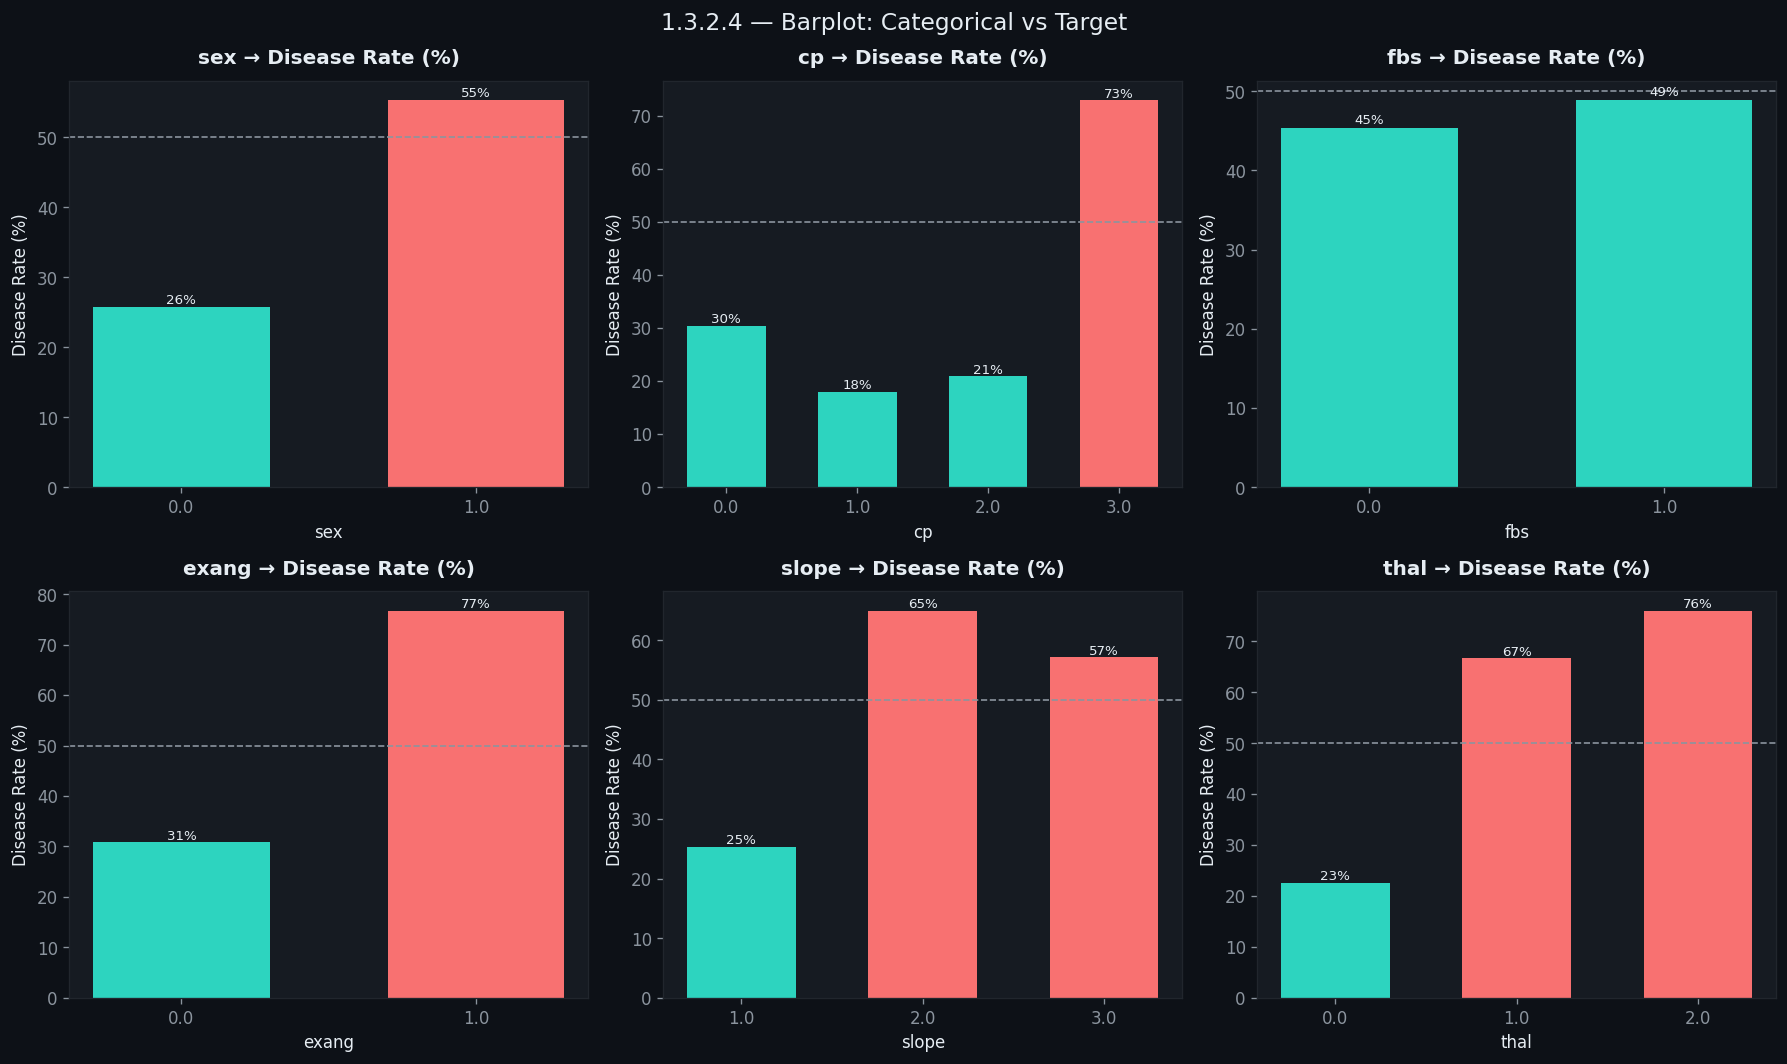

In [440]:
# 1.3.2.4 Figure 9: Barplot (categorical vs target)
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('1.3.2.4 — Barplot: Categorical vs Target', fontsize=14, color=TEXT)
axes = axes.flatten()
for i, cat in enumerate(['sex','cp','fbs','exang','slope','thal']):
    ax = axes[i]
    grouped = df.groupby(cat)['target_binary'].mean() * 100
    bars = ax.bar(range(len(grouped)), grouped.values,
                  color=[ROSE if v > 50 else TEAL for v in grouped.values], width=0.6)
    ax.set_xticks(range(len(grouped)))
    ax.set_xticklabels([str(k) for k in grouped.index])
    ax.set_title(f'{cat} → Disease Rate (%)')
    ax.set_ylabel('Disease Rate (%)'); ax.set_xlabel(cat)
    ax.axhline(50, color=MUTED, linestyle='--', linewidth=1)
    for bar, val in zip(bars, grouped.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.0f}%', ha='center', fontsize=8, color=TEXT)
plt.tight_layout()
plt.show()

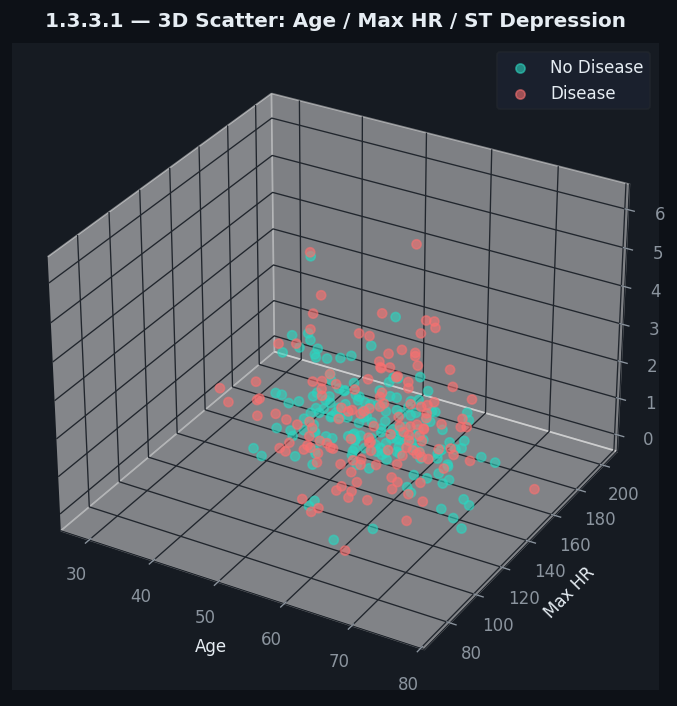

In [441]:
# 1.3.3.1 Figure 10: 3D Scatter Plot
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
for cls, col, lbl in [(0, TEAL, 'No Disease'), (1, ROSE, 'Disease')]:
    mask = df['target_binary'] == cls
    ax.scatter(df.loc[mask,'age'], df.loc[mask,'thalach'],
               df.loc[mask,'oldpeak'], c=col, alpha=0.6, s=30, label=lbl)
ax.set_xlabel('Age'); ax.set_ylabel('Max HR'); ax.set_zlabel('ST Depression')
ax.set_title('1.3.3.1 — 3D Scatter: Age / Max HR / ST Depression', color=TEXT)
ax.set_facecolor(PANEL)
fig.patch.set_facecolor(BG)
ax.tick_params(colors=MUTED)
ax.legend()
plt.show()

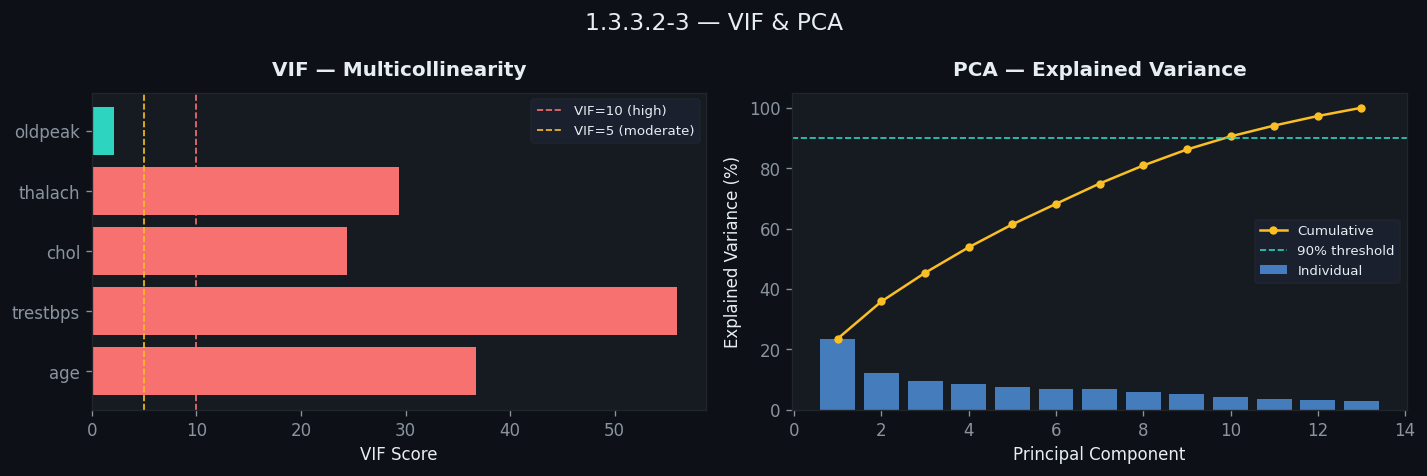

In [442]:
# 1.3.3.2-3 Figure 11: VIF & PCA
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('1.3.3.2-3 — VIF & PCA', fontsize=14, color=TEXT)

vif_colors = [ROSE if v > 10 else AMBER if v > 5 else TEAL for v in vif_df['VIF']]
axes[0].barh(vif_df['Feature'], vif_df['VIF'], color=vif_colors)
axes[0].axvline(10, color=ROSE, linestyle='--', linewidth=1, label='VIF=10 (high)')
axes[0].axvline(5,  color=AMBER, linestyle='--', linewidth=1, label='VIF=5 (moderate)')
axes[0].set_title('VIF — Multicollinearity'); axes[0].set_xlabel('VIF Score')
axes[0].legend(fontsize=8)

axes[1].bar(range(1, len(var_ratio)+1), var_ratio*100, color=BLUE, alpha=0.7, label='Individual')
axes[1].plot(range(1, len(cum_var)+1), cum_var*100, color=AMBER, marker='o', ms=4, lw=1.5, label='Cumulative')
axes[1].axhline(90, color=TEAL, linestyle='--', linewidth=1, label='90% threshold')
axes[1].set_xlabel('Principal Component'); axes[1].set_ylabel('Explained Variance (%)')
axes[1].set_title('PCA — Explained Variance'); axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

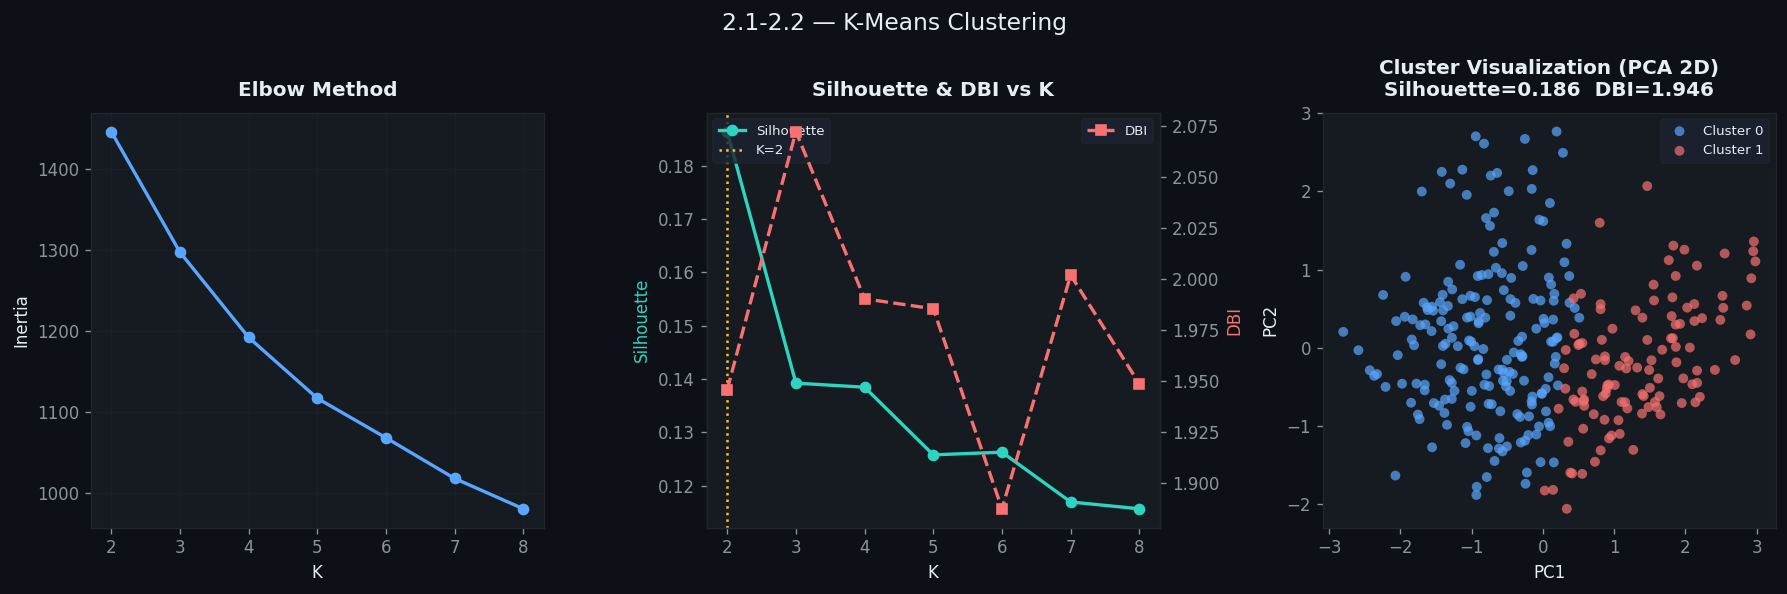

In [443]:
# 2.2 Figure 12: K-Means Visualization
# PCA 2D for cluster visualization
pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X_cluster)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('2.1-2.2 — K-Means Clustering', fontsize=14, color=TEXT)

# Elbow curve
axes[0].plot(k_range, inertias, color=BLUE, marker='o', ms=6, linewidth=2)
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Inertia')
axes[0].grid(True, alpha=0.4)

# Silhouette + DBI scores
ax2 = axes[1].twinx()
axes[1].plot(k_range, sil_scores, color=TEAL, marker='o', ms=6, lw=2, label='Silhouette')
ax2.plot(k_range, dbi_scores, color=ROSE, marker='s', ms=6, lw=2, linestyle='--', label='DBI')
axes[1].axvline(best_k, color=AMBER, linestyle=':', lw=1.5, label=f'K={best_k}')
axes[1].set_title('Silhouette & DBI vs K')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Silhouette', color=TEAL)
ax2.set_ylabel('DBI', color=ROSE)
axes[1].legend(loc='upper left', fontsize=8); ax2.legend(loc='upper right', fontsize=8)

# Cluster 2D scatter
cluster_pal = [BLUE, ROSE, TEAL, AMBER, PURPLE, GREEN]
for c in range(best_k):
    mask = cluster_labels == c
    axes[2].scatter(X_pca2[mask, 0], X_pca2[mask, 1],
                    c=cluster_pal[c], alpha=0.7, s=35, label=f'Cluster {c}', edgecolors='none')
axes[2].set_title(f'Cluster Visualization (PCA 2D)\nSilhouette={sil_final:.3f}  DBI={dbi_final:.3f}')
axes[2].set_xlabel('PC1'); axes[2].set_ylabel('PC2')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

C:\Users\moham\AppData\Local\Temp\ipykernel_228\2518286850.py:88: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax8.boxplot(cv_data, labels=models_names, patch_artist=True,


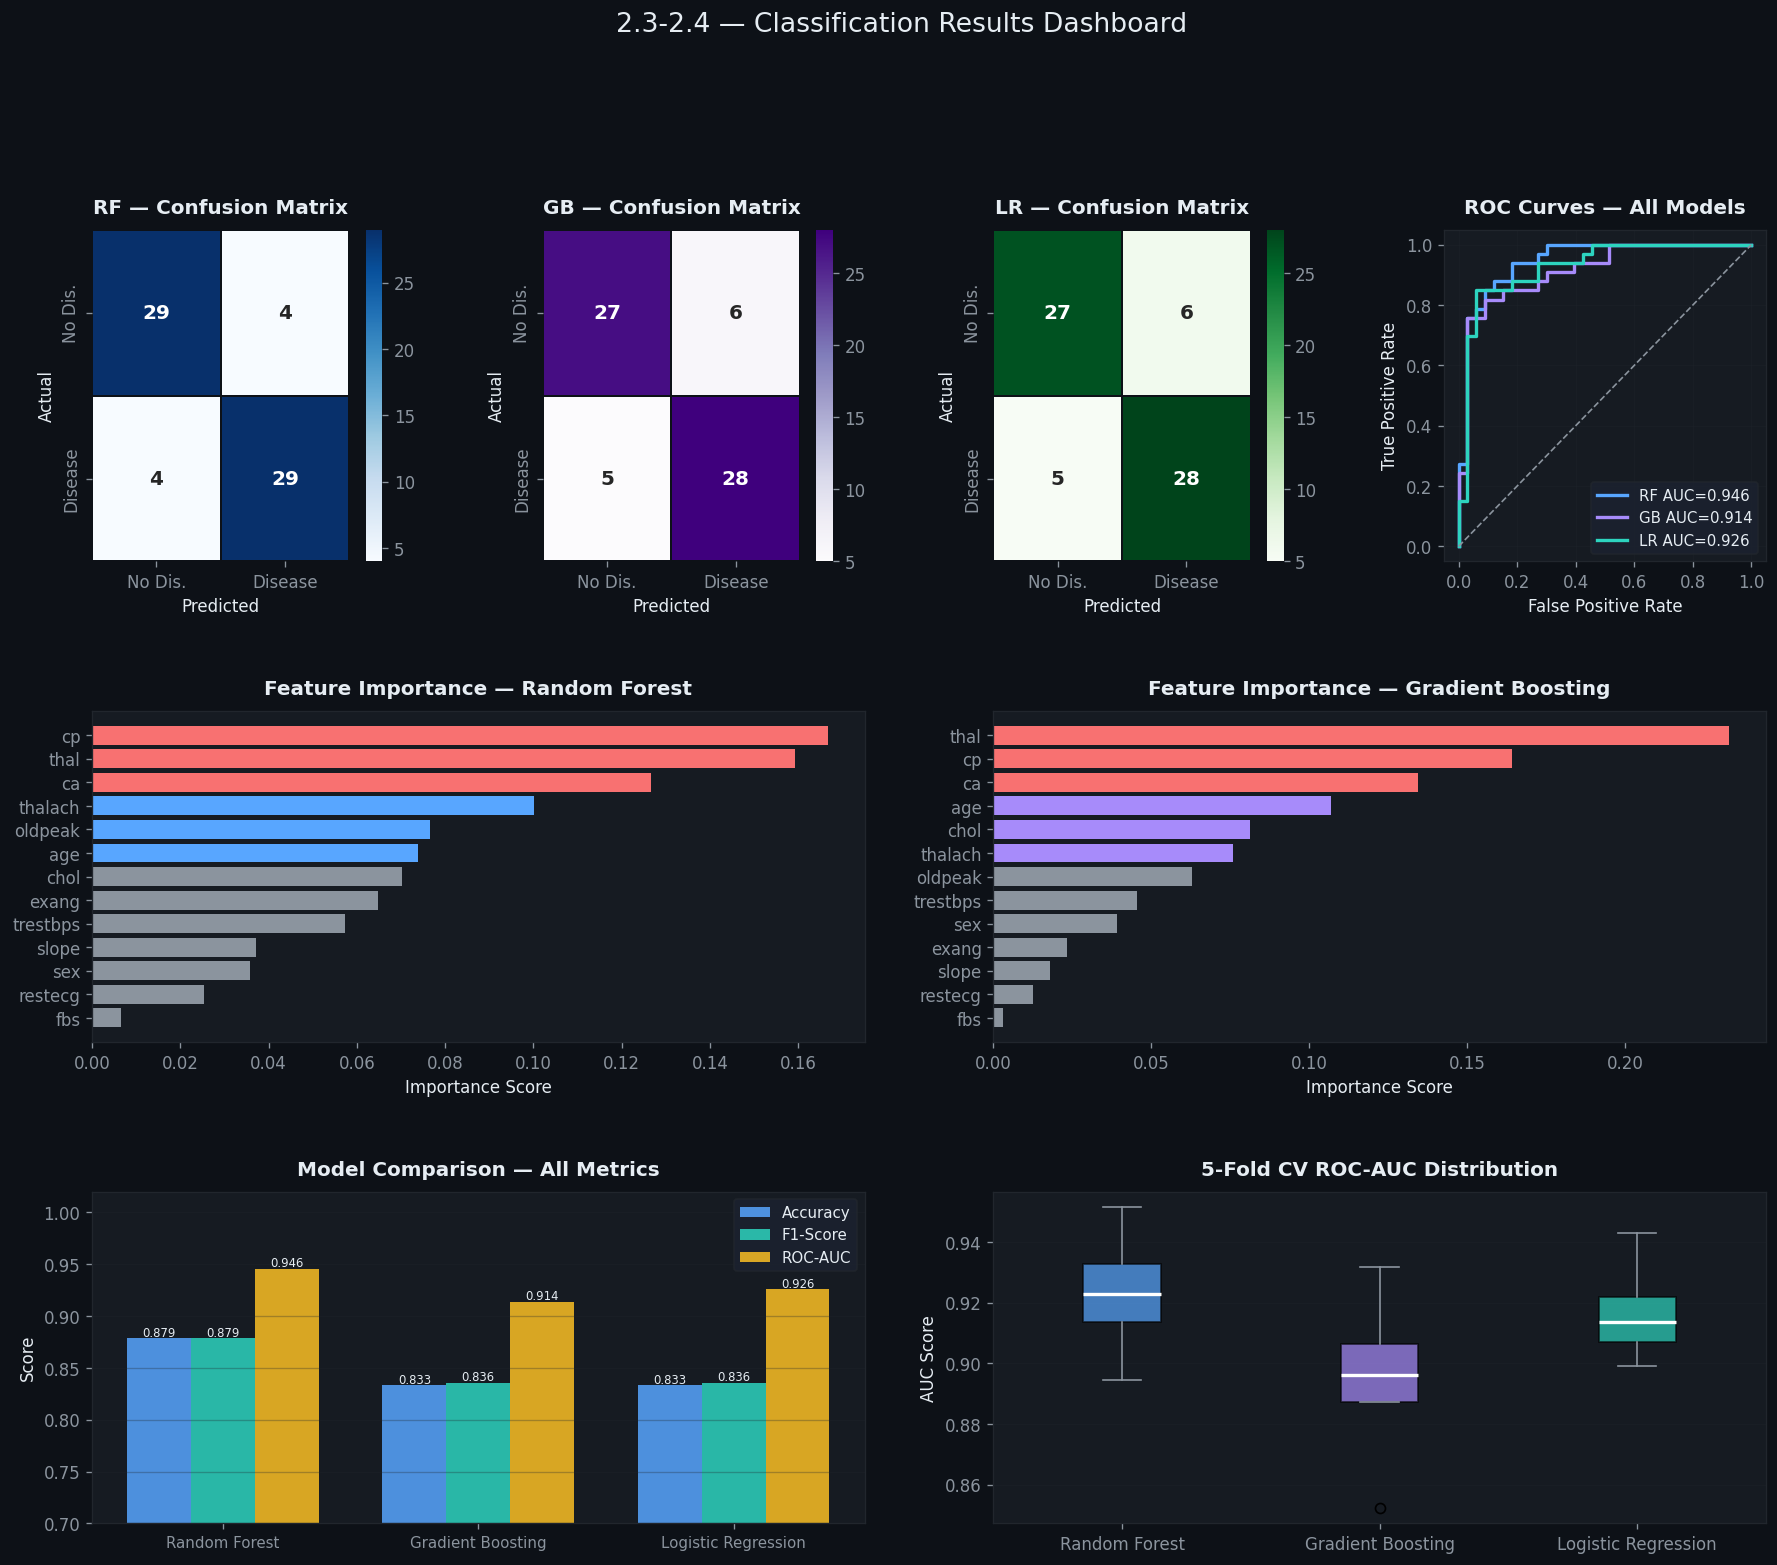

In [444]:
# 2.4 Figure 13: Classification Results Dashboard
fig = plt.figure(figsize=(18, 14))
fig.suptitle('2.3-2.4 — Classification Results Dashboard', fontsize=16, color=TEXT, y=1.01)
gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.4)

# 1. Confusion Matrix — RF
ax1 = fig.add_subplot(gs[0, 0])
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=ax1,
            linewidths=1, linecolor=BG, annot_kws={'size':12, 'weight':'bold'})
ax1.set_title('RF — Confusion Matrix')
ax1.set_xlabel('Predicted'); ax1.set_ylabel('Actual')
ax1.set_xticklabels(['No Dis.','Disease']); ax1.set_yticklabels(['No Dis.','Disease'])

# 2. Confusion Matrix — GB
ax2 = fig.add_subplot(gs[0, 1])
cm_gb = confusion_matrix(y_test, y_pred_gb)
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Purples', ax=ax2,
            linewidths=1, linecolor=BG, annot_kws={'size':12, 'weight':'bold'})
ax2.set_title('GB — Confusion Matrix')
ax2.set_xlabel('Predicted'); ax2.set_ylabel('Actual')
ax2.set_xticklabels(['No Dis.','Disease']); ax2.set_yticklabels(['No Dis.','Disease'])

# 3. Confusion Matrix — LR
ax3 = fig.add_subplot(gs[0, 2])
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens', ax=ax3,
            linewidths=1, linecolor=BG, annot_kws={'size':12, 'weight':'bold'})
ax3.set_title('LR — Confusion Matrix')
ax3.set_xlabel('Predicted'); ax3.set_ylabel('Actual')
ax3.set_xticklabels(['No Dis.','Disease']); ax3.set_yticklabels(['No Dis.','Disease'])

# 4. ROC Curves — All Models
ax4 = fig.add_subplot(gs[0, 3])
for (proba, label, color) in [(y_proba_rf,'RF',BLUE),(y_proba_gb,'GB',PURPLE),(y_proba_lr,'LR',TEAL)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_v = roc_auc_score(y_test, proba)
    ax4.plot(fpr, tpr, color=color, lw=2, label=f'{label} AUC={auc_v:.3f}')
ax4.plot([0,1],[0,1], color=MUTED, lw=1, linestyle='--')
ax4.set_xlabel('False Positive Rate'); ax4.set_ylabel('True Positive Rate')
ax4.set_title('ROC Curves — All Models')
ax4.legend(fontsize=9); ax4.grid(True, alpha=0.3)

# 5. Feature Importance — RF
ax5 = fig.add_subplot(gs[1, :2])
feat_imp = pd.Series(rf.feature_importances_, index=X_raw.columns).sort_values(ascending=True)
colors_imp = [ROSE if v > feat_imp.quantile(0.75) else BLUE if v > feat_imp.median() else MUTED for v in feat_imp.values]
ax5.barh(feat_imp.index, feat_imp.values, color=colors_imp)
ax5.set_title('Feature Importance — Random Forest')
ax5.set_xlabel('Importance Score')

# 6. Feature Importance — GB
ax6 = fig.add_subplot(gs[1, 2:])
feat_imp_gb = pd.Series(gb.feature_importances_, index=X_raw.columns).sort_values(ascending=True)
colors_gb = [ROSE if v > feat_imp_gb.quantile(0.75) else PURPLE if v > feat_imp_gb.median() else MUTED for v in feat_imp_gb.values]
ax6.barh(feat_imp_gb.index, feat_imp_gb.values, color=colors_gb)
ax6.set_title('Feature Importance — Gradient Boosting')
ax6.set_xlabel('Importance Score')

# 7. Model Comparison Bar Chart
ax7 = fig.add_subplot(gs[2, :2])
models_names  = ['Random Forest', 'Gradient Boosting', 'Logistic Regression']
accs   = [acc_rf,  acc_gb,  acc_lr]
f1s    = [f1_rf,   f1_gb,   f1_lr]
aucs   = [auc_rf,  auc_gb,  auc_lr]
x = np.arange(len(models_names))
w = 0.25
b1 = ax7.bar(x - w,   accs, w, label='Accuracy', color=BLUE,   alpha=0.85)
b2 = ax7.bar(x,       f1s,  w, label='F1-Score',  color=TEAL,   alpha=0.85)
b3 = ax7.bar(x + w,   aucs, w, label='ROC-AUC',   color=AMBER,  alpha=0.85)
ax7.set_xticks(x); ax7.set_xticklabels(models_names, fontsize=9)
ax7.set_ylim(0.7, 1.02)
ax7.set_title('Model Comparison — All Metrics')
ax7.set_ylabel('Score'); ax7.legend(fontsize=9)
ax7.grid(True, axis='y', alpha=0.3)
for bars in [b1, b2, b3]:
    for bar in bars:
        ax7.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{bar.get_height():.3f}', ha='center', fontsize=7, color=TEXT)

# 8. CV Score distribution
ax8 = fig.add_subplot(gs[2, 2:])
cv_data = [
    cross_val_score(rf, X_sm, y_sm, cv=cv, scoring='roc_auc'),
    cross_val_score(gb, X_sm, y_sm, cv=cv, scoring='roc_auc'),
    cross_val_score(lr, X_sm, y_sm, cv=cv, scoring='roc_auc'),
]
bp = ax8.boxplot(cv_data, labels=models_names, patch_artist=True,
                 medianprops={'color':'white','linewidth':2})
for patch, col in zip(bp['boxes'], [BLUE, PURPLE, TEAL]):
    patch.set_facecolor(col); patch.set_alpha(0.7)
for el in ['whiskers','caps']:
    for item in bp[el]: item.set_color(MUTED)
ax8.set_title('5-Fold CV ROC-AUC Distribution')
ax8.set_ylabel('AUC Score'); ax8.grid(True, axis='y', alpha=0.3)

plt.show()

## Summary Results

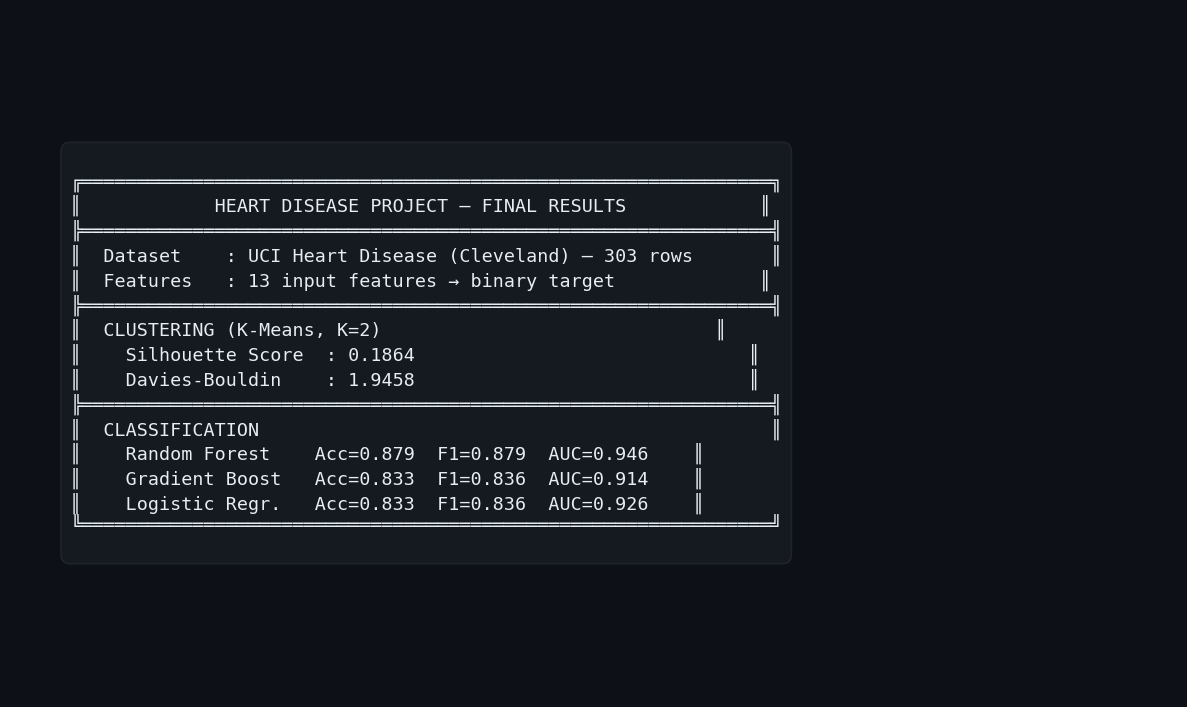

In [445]:
# SUMMARY RESULTS FIGURE
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 6))
ax.axis('off')
fig.patch.set_facecolor(BG)

summary_text = f"""
╔══════════════════════════════════════════════════════════════╗
║            HEART DISEASE PROJECT — FINAL RESULTS            ║
╠══════════════════════════════════════════════════════════════╣
║  Dataset    : UCI Heart Disease (Cleveland) — 303 rows       ║
║  Features   : 13 input features → binary target             ║
╠══════════════════════════════════════════════════════════════╣
║  CLUSTERING (K-Means, K={best_k})                              ║
║    Silhouette Score  : {sil_final:.4f}                              ║
║    Davies-Bouldin    : {dbi_final:.4f}                              ║
╠══════════════════════════════════════════════════════════════╣
║  CLASSIFICATION                                              ║
║    Random Forest    Acc={acc_rf:.3f}  F1={f1_rf:.3f}  AUC={auc_rf:.3f}    ║
║    Gradient Boost   Acc={acc_gb:.3f}  F1={f1_gb:.3f}  AUC={auc_gb:.3f}    ║
║    Logistic Regr.   Acc={acc_lr:.3f}  F1={f1_lr:.3f}  AUC={auc_lr:.3f}    ║
╚══════════════════════════════════════════════════════════════╝
"""

ax.text(0.05, 0.5, summary_text, transform=ax.transAxes,
        fontsize=11, verticalalignment='center', fontfamily='monospace',
        color=TEXT, bbox=dict(facecolor=PANEL, edgecolor=GRID,
                               boxstyle='round,pad=0.5', alpha=0.9))
plt.tight_layout()
plt.show()

# Save results JSON
with open('/home/claude/results.json', 'w') as f:
    json.dump(results, f, indent=2)